# Description

In this notebook, I will create a Deep Learning model to recognze fruit in the folder `dataset`

In [1]:
import os 
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms
from torchvision.utils import save_image

import bitsandbytes as bnb
from bitsandbytes.functional import int8_linear_matmul

# 1. Load dataset

In [2]:
PATH_TRAIN = './dataset/train_zip/train/'
PATH_TEST = './dataset/test_zip/test/'

IMG_SIZE = 128
BATCH_SIZE = 32

In [3]:
list_train = os.listdir(PATH_TRAIN)
list_test = os.listdir(PATH_TEST)

print(f'Number of training samples: {len(list_train)}')
print(f'Number of testing samples: {len(list_test)}')

Number of training samples: 480
Number of testing samples: 120


In [4]:
# Load dataset as numpy arrays
def load_data(path, list_files, target_size=(IMG_SIZE, IMG_SIZE, 3)):
    X, Y = [], []
    for file in list_files:
        if file.endswith('.jpg') or file.endswith('.png'):
            img = Image.open(os.path.join(path, file)).convert('RGB')
            img = img.resize((target_size[1], target_size[0]))
            img = np.array(img)
            X.append(img)

            label = file.split('_')[0]
            Y.append(label)
    X = np.array(X).astype('uint8')
    return X, Y

train_X, train_Y = load_data(PATH_TRAIN, list_train)
test_X, test_Y = load_data(PATH_TEST, list_test)

print(f'Training data shape: {train_X.shape}')
print(f'Testing data shape: {test_X.shape}')

# Distribution of classes in training set
(unique, counts) = np.unique(train_Y, return_counts=True)
frequencies = np.asarray((unique, counts)).T
print(frequencies)

/home/tnguyen10/.conda/envs/gpu_env/lib/python3.10/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Training data shape: (240, 128, 128, 3)
Testing data shape: (60, 128, 128, 3)
[['apple' '75']
 ['banana' '73']
 ['mixed' '20']
 ['orange' '72']]


In [5]:
# Remove mixed class
train_Y = np.array(train_Y)
idx = np.where(train_Y != 'mixed')
train_X = train_X[idx]
train_Y = np.array(train_Y)[idx]

# Remove in test set
test_Y = np.array(test_Y)
idx = np.where(test_Y != 'mixed')
test_X = test_X[idx]
test_Y = np.array(test_Y)[idx]

print(f'After removing mixed class:')
print(f'Training data shape: {train_X.shape}')
print(f'Testing data shape: {test_X.shape}')

# Distribution of classes in training set
(unique, counts) = np.unique(train_Y, return_counts=True)
frequencies = np.asarray((unique, counts)).T
print(frequencies)

After removing mixed class:
Training data shape: (220, 128, 128, 3)
Testing data shape: (55, 128, 128, 3)
[['apple' '75']
 ['banana' '73']
 ['orange' '72']]


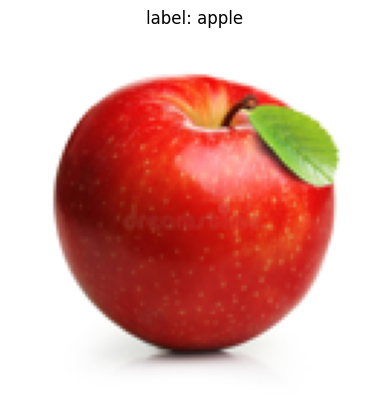

In [6]:
# Randomly display some training images
idx = np.random.randint(0, len(train_X))
plt.imshow(train_X[idx])
plt.title(f'label: {train_Y[idx]}')
plt.axis('off')
plt.show()

# 2. Prepare dataset for torch training

In [7]:
class NumpyDataWrapper(Dataset):
    def __init__(self, X, Y, label_encoder=None, transform=None):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0  # [0,1]
        self.le = label_encoder or LabelEncoder().fit(Y)
        self.Y = torch.tensor(self.le.transform(Y), dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x, y = self.X[idx], self.Y[idx]          # x: torch.Tensor (C,H,W), float32 in [0,1]
        if self.transform:
            x = self.transform(x)                # torchvision transforms can work on tensors
        return x, y

In [8]:
train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.05, 0.05),
                            scale=(0.95, 1.05), shear=5),     # small geo jitter
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),         # color jitter
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2),
                             ratio=(0.3, 3.3), inplace=True), # occlusion
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

val_tfms = transforms.Compose([
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

In [ ]:
def calculate_quantization_params(tensor: torch.Tensor, num_bits=8):
    qmin = -2.**(num_bits - 1)
    qmax = 2.**(num_bits - 1) - 1

    min_val, max_val = tensor.min(), tensor.max()

    scale = (max_val - min_val) / (qmax - qmin)
    scale = max(scale, 1e-8) 
    zero_point = qmin - min_val / scale
    zero_point = torch.round(zero_point)
    zero_point = max(int(qmin), min(int(qmax), zero_point))  

    return scale, zero_point

def quantize_tensor(tensor: torch.Tensor, scale: float, zero_point, num_bits=8):
    qmin = -2.**(num_bits - 1)
    qmax = 2.**(num_bits - 1) - 1

    q_x = zero_point + tensor / scale
    q_x.clamp_(qmin, qmax).round_()
    return q_x.to(torch.int8)

def dequantize_tensor(q_x: torch.Tensor, scale: float, zero_point):
    return scale * (q_x.float() - zero_point)


class MyLinear(nn.Module):
    def __init__(self, in_features, out_features,
                 w_bits=8, ac_bits=8):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features))

        # Initialize parameters like nn.Linear
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / fan_in**0.5
        nn.init.uniform_(self.bias, -bound, bound)

        # Quantization parameters
        self.w_bits = w_bits
        self.ac_bits = ac_bits

        # Calibration stat
        self.register_buffer('ac_min', torch.tensor(float('inf')))
        self.register_buffer('ac_max', torch.tensor(float('-inf')))
        self.calibrating = True

        # Quantize weights buffer
        self.register_buffer('qweight', torch.zeros_like(self.weight, dtype=torch.int8))
        self.register_buffer('w_scale', torch.tensor(1.0))
        self.register_buffer('w_zero_point', torch.tensor(0))
        self.register_buffer('x_scale', torch.tensor(1.0))
        self.register_buffer('x_zero_point', torch.tensor(0))
        self.frozen = False

    def observe_activation(self, x):
        min_val = x.min()
        max_val = x.max()
        with torch.no_grad():
            self.ac_min = min(self.ac_min, min_val)
            self.ac_max = max(self.ac_max, max_val)

    @torch.no_grad()
    def freeze(self):
        """
        Frozen mean: the layer has finished calibration and weight are quantized.
        Now, it run the inference in quantized mode.
        """

        # Compute activation quantization params
        ac_scale, ac_zero_point = calculate_quantization_params(
            torch.cat([self.ac_min.unsqueeze(0), self.ac_max.unsqueeze(0)]), self.ac_bits)
        self.x_scale.copy_(torch.tensor(ac_scale))
        self.x_zero_point.copy_(torch.tensor(ac_zero_point))

        # Compute weight quantization params
        w_scale, w_zero_point = calculate_quantization_params(self.weight, self.w_bits)
        self.w_scale.copy_(torch.tensor(w_scale))
        self.w_zero_point.copy_(torch.tensor(w_zero_point))

        # Quantize weight
        qweight = quantize_tensor(self.weight, w_scale, w_zero_point, self.w_bits)
        self.qweight.copy_(qweight)
        self.frozen = True
        self.calibrating = False


    def forward(self, x):

        # Normal float operation
        if not self.frozen and not self.calibrating:
            return F.linear(x, self.weight, self.bias)

        # Just observe the activation range
        if not self.frozen and self.calibrating:
            self.observe_activation(x)
            return F.linear(x, self.weight, self.bias)
        
        # Quantize input
        qx = quantize_tensor(x, self.x_scale.item(), self.x_zero_point.item(), self.ac_bits)
    
        # int32 matmul
        y_int32 = int8_linear_matmul(qx, self.qweight)
        
        # Dequantize
        y = self.w_scale.item() * self.x_scale.item() * y_int32.float() 
        y += self.bias
        return y

In [10]:
class Neural_Network(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.fc1 = MyLinear(32 * 32 * 32, 128)   
        self.fc2 = MyLinear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu1(self.conv1(x)))
        x = self.pool(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)              # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
    def set_calibrating(self, mode=True):
        self.calibrating = mode
        for module in self.modules():
            if isinstance(module, MyLinear):
                module.calibrating = mode

    @torch.no_grad()
    def freeze(self):
        for module in self.modules():
            if isinstance(module, MyLinear):
                module.freeze()

In [11]:
train_X_, val_X, train_Y_, val_Y = train_test_split(train_X, train_Y, test_size=0.2, random_state=42)

le = LabelEncoder().fit(train_Y_)

train_ds = NumpyDataWrapper(train_X_, train_Y_, label_encoder=le, transform=train_tfms)
val_ds   = NumpyDataWrapper(val_X, val_Y, label_encoder=le, transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)

In [12]:
print(f"Encoded classes: {le.classes_}")

Encoded classes: ['apple' 'banana' 'orange']


# 3. Training

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Neural_Network(num_classes=len(le.classes_)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [14]:
EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            _, pred_labels = preds.max(1)
            correct += (pred_labels == yb).sum().item()
            total += yb.size(0)
    val_acc = correct / total

    print(f"Epoch {epoch+1}: Train Loss = {total_loss/len(train_loader):.4f}, ValAcc = {val_acc:.4f}")

Epoch 1: Train Loss = 1.5983, ValAcc = 0.5455
Epoch 2: Train Loss = 0.9009, ValAcc = 0.6818
Epoch 3: Train Loss = 0.7451, ValAcc = 0.8864
Epoch 4: Train Loss = 0.6093, ValAcc = 0.9091
Epoch 5: Train Loss = 0.5106, ValAcc = 0.9545
Epoch 6: Train Loss = 0.5110, ValAcc = 0.9318
Epoch 7: Train Loss = 0.4367, ValAcc = 0.9545
Epoch 8: Train Loss = 0.3918, ValAcc = 0.9318
Epoch 9: Train Loss = 0.4589, ValAcc = 0.9545
Epoch 10: Train Loss = 0.3996, ValAcc = 0.9545
Epoch 11: Train Loss = 0.3367, ValAcc = 0.9545
Epoch 12: Train Loss = 0.3894, ValAcc = 0.8636
Epoch 13: Train Loss = 0.3703, ValAcc = 0.9773
Epoch 14: Train Loss = 0.3592, ValAcc = 0.9091
Epoch 15: Train Loss = 0.3495, ValAcc = 0.9545
Epoch 16: Train Loss = 0.2929, ValAcc = 0.9773
Epoch 17: Train Loss = 0.3362, ValAcc = 0.9773
Epoch 18: Train Loss = 0.2500, ValAcc = 0.9773
Epoch 19: Train Loss = 0.3169, ValAcc = 0.9318
Epoch 20: Train Loss = 0.2464, ValAcc = 0.9773


# 4. Evaluation

In [15]:
def evaluate_model(model, val_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.inference_mode():
        for xb, yb in val_loader:
            preds = model(xb.to(device))
            yb = yb.to(device)
            _, pred_labels = preds.max(1)
            correct += (pred_labels == yb).sum().item()
            total += yb.size(0)

    return correct / total

In [16]:
val_acc = evaluate_model(model, val_loader, device)
print(f"Val Acc = {val_acc:.4f}")

Val Acc = 0.9773


Run inference

In [17]:
PATH_INPUT_IMAGE = "dataset/banana.jpg"

image = Image.open(PATH_INPUT_IMAGE).convert('RGB')
image = image.resize((IMG_SIZE, IMG_SIZE))
image = np.array(image).astype('uint8')
image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0  # Normalize to [0, 1]
image = image.to(device)

/home/tnguyen10/.conda/envs/gpu_env/lib/python3.10/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [18]:
pred_logits = model(image)
print(f"Logits: {pred_logits}")

pred_labels = pred_logits.argmax(dim=1).item()
print(pred_labels)

pred_class = le.inverse_transform([pred_labels])[0]
print(f'Predicted class: {pred_class}')

Logits: tensor([[-0.8769,  1.8578, -0.7873]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
1
Predicted class: banana


Measure time inference per sample

In [32]:
# Warm-up
num_warmup = 10
for _ in range(num_warmup):
    _ = model(image)
    
# Measure torch inference time
num_runs = 1_000
start = torch.cuda.Event(enable_timing=True)
end = torch.cuda.Event(enable_timing=True)

start.record()
for _ in range(num_runs):
    _ = model(image)
end.record()
torch.cuda.synchronize()
elapsed_time = start.elapsed_time(end)  # milliseconds
print(f'Torch inference time: {elapsed_time / num_runs:.4f} ms per sample')

Torch inference time: 0.4906 ms per sample


# 5. Quantization

In [33]:
# Run calibration on training set
model.eval()
model.set_calibrating(True)

for xb, yb in train_loader:
    xb = xb.to(device)
    _ = model(xb)

model.set_calibrating(False)

# Done calibration, now freeze the model
model.freeze()
print(f"[INFO] Done calibration and freezing the model.")

[INFO] Done calibration and freezing the model.


/tmp/ipykernel_2399388/931032702.py:77: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x_scale.copy_(torch.tensor(ac_scale))
/tmp/ipykernel_2399388/931032702.py:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.w_scale.copy_(torch.tensor(w_scale))
/tmp/ipykernel_2399388/931032702.py:83: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.w_zero_point.copy_(torch.tensor(w_zero_point))


In [34]:
# Test frozen model accuracy
val_acc = evaluate_model(model, val_loader, device)
print(f"Val Acc after quantization = {val_acc:.4f}")

Val Acc after quantization = 0.2727


Measure time of model after quantization

In [35]:
# Warm-up
num_warmup = 10
for _ in range(num_warmup):
    _ = model(image)

# Measure time of model after quantization
num_runs = 1_000
start = torch.cuda.Event(enable_timing=True)
end = torch.cuda.Event(enable_timing=True)
start.record()
for _ in range(num_runs):
    _ = model(image)
end.record()
torch.cuda.synchronize()
elapsed_time = start.elapsed_time(end)  # milliseconds
print(f'Quantized model inference time: {elapsed_time / num_runs:.4f} ms per sample')

Quantized model inference time: 0.4813 ms per sample
